# ST2195 Coursework Project Part 2 2024/2025
### Name: Glenda Ho            
### Student ID:230572931
### Part 2 Python

#### Import all the libraries required for Part 2.
The import of **"pandas"** works as a power library for data manipulation for function such as reading data, cleaning to aggregation, etc.
<br>
<br>
The import of **"numpy"** allows us to numerical functions in python.
<br>
<br>
The import of **"matplotlib.pyplot"** allows us to plot graphs.
<br>
<br>
The import of **"seaborn"** allows us to create complex visualisations.
<br>
<br>
The import of **"os"** allows us to work with files, directories, environment variables, and system commands.
<br>
<br>
The import of **"smf"** allows us to build and analyze statistical models using formulas.
<br>
<br>
The import of **"sm"** provides advanced statistical modeling tools for regression, hypothesis testing, and time series analysis.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statsmodels.formula.api as smf
import statsmodels.api as sm

The import of **"LabelEncoder, StandardScaler"** allows for encoding categorical variables into numerical values and standardizing features by removing the mean and scaling to unit variance.<br><br>
The import of **"train_test_split"** allows for data mining and data analysis.<br><br>
The import of **"LogisitcRegression"** allows for the running of logistic regression.

In [5]:
from sklearn.preprocessing import LabelEncoder,  StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

## For Question 2a and b
#### A file clean was done due to memory issue, ensuring smoother operation.
Initialize a list **"CSVs"** containing names of the CSV files for each from 1995 to 1999, files name are constructed using list comprehension.
<br>
<br>
Create a **"for"** loop to loop through each csv in the **"CSVs"** list created above.
<br>
<br>
Within the loop, attempt to read the csv, if a **"UnicodeDecodeError"** occurs causing encoding issues, the code catches the exception **"except"** and prints an error message of the specific decoding error and encodes it with "latin1" to solve the issue. Latin1 is capable of representing any character in the Unicode character set, making it a good option when dealing with unknown or mixed encoding.
<br>
<br>
Within the loop, 
<br>-specify the **"Colums_Needed"** and we update the data as **"Updated_data"**.
<br>-remove rows with missing values to clean the data and only retain the information we need **".dropna()"**.
<br>-remove the **".csv"** extension to allow for further processing.
<br>-save the updated data into a new csv file **"NewCSV"** and rename it as the respective year with **"Q2ab.csv"**, Example: 1995Q2ab.CSV.
<br><br>
[Note: File will be saved in the working directory where the code file is stored. Original file (1995.csv) will not be corrupted.]

In [7]:
CSVs = [str(year) + ".csv" for year in range(1995, 2000)]

for CSV in CSVs:
    try:
        data = pd.read_csv(CSV, encoding='utf-8')
    except UnicodeDecodeError as e:
        print(f"Error decoding file {CSV}: {e}")
        print("Skipping problematic characters and continuing...")
        data = pd.read_csv(CSV, encoding='latin1') 
    
    Columns_Needed = ["Year", "DayOfWeek", "TailNum", "ArrDelay", "DepDelay", "CRSDepTime","DepTime"]
    Updated_data = data[Columns_Needed]
    
    Updated_data = Updated_data.dropna()
    
    CSV_without_extension = CSV.replace(".csv", "")

    NewCSV = CSV_without_extension + "Q2ab.csv"
    Updated_data.to_csv(NewCSV, index=False)
    
    print("Processed:", CSV)

Processed: 1995.csv
Processed: 1996.csv
Processed: 1997.csv
Processed: 1998.csv
Processed: 1999.csv


Initialize an empty dictionary to store dataframes read from the cleaned CSV files.<br><br>
Create a for loop to iterate through the cleaned CSV files from 1995 to 1999.<br><br>
Within the loop, implement an **"if-else"** logic to check if the file exists in the current working directory. If it exists, read and store it in the dictionary **"Empty_dictQ2ab"**. If the file is not found, prompt **"File not found for year {year}"**. Here, {year} will represent the year for which the file is not found.<br><br>
After iterating through all the years from 1995 to 1999, concatenate all the dataframes into one dataframe named **"df"**.<br><br>
Read **"pdf1"** for Part 2b), a supplementary file consisting of flight tail numbers and their respective details.


In [9]:
Empty_dictQ2ab = {}

for year in range(1995, 2000):
    CSV = f"{year}Q2ab.csv"
    
    if os.path.exists(CSV):
        Empty_dictQ2ab[f'df{year}'] = pd.read_csv(CSV)
    else:
        print(f"File not found for year {year}")

df = pd.concat(Empty_dictQ2ab.values(), ignore_index=True)

pdf1 = pd.read_csv("plane-data.csv")

## Part 2a) 

#### For Part 2a), the objective is to select a consecutive 5-year subset from the dataset and find out the best times and days of the week to minimise delays each year.

**"years"** creates a range object from 1995 to 1999.<br><br>
**"least_delay_days"** initializes an empty dictionary to store information about the day of the week with the least delay for each year.<br><br>
**"weekday_names"** is a dictionary that maps numerical day-of-week values (from flight data) to weekday names.

In [12]:
years = range(1995, 2000)
least_delay_days = {}
weekday_names = {1: "Monday", 2: "Tuesday", 3: "Wednesday", 4: "Thursday", 5: "Friday", 6: "Saturday", 7: "Sunday"}

Create a for loop to iterate through the **"years"** (1995 to 1999). The following code explanation below are all within the loop.<br><br>
Convert departure time to hour of the day.<br><br>
**"delay_by_time"** group data by day of the week and hour, then compute average departure and arrival delay.<br><br>
**"delay_pivot"** creates a pivot table for visualization.<br><br>
Plot heatmap for both average departure and arrival delay for each year.

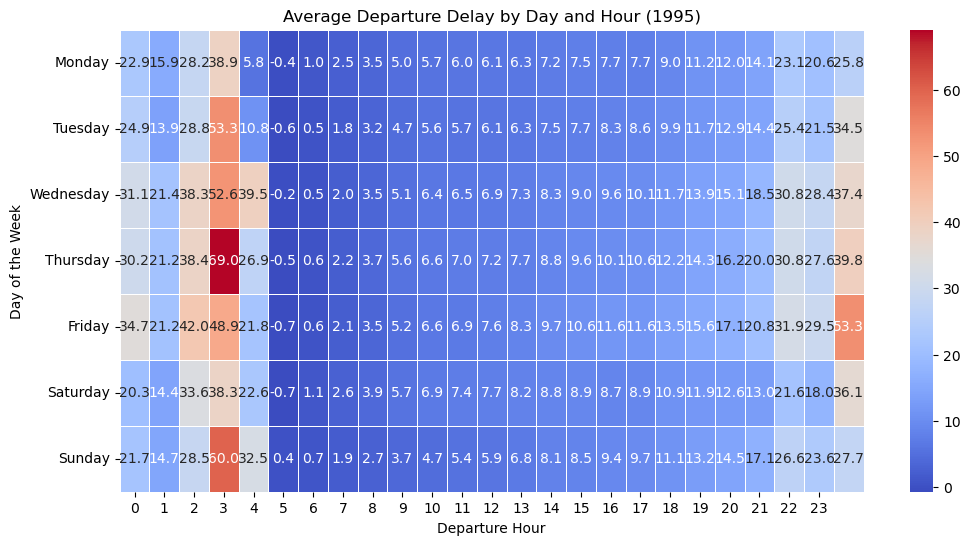

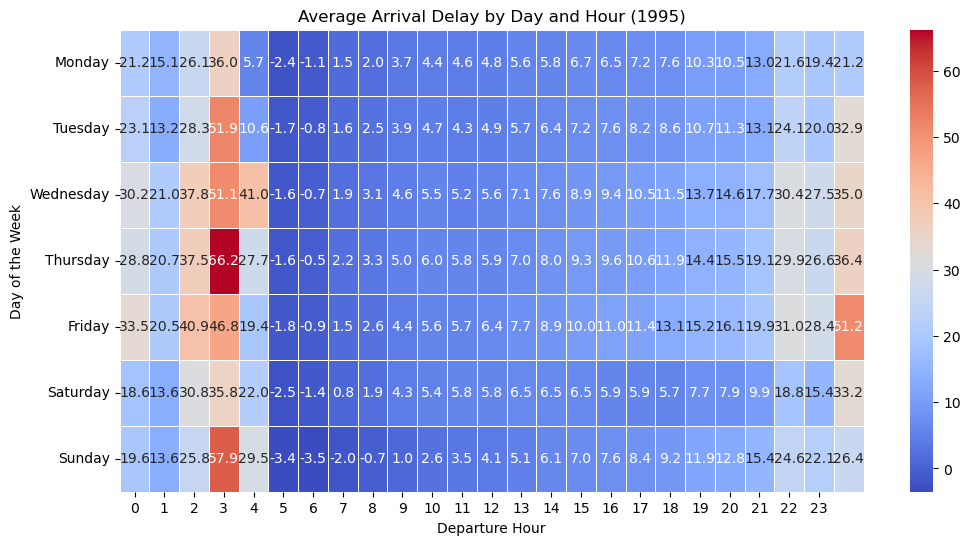

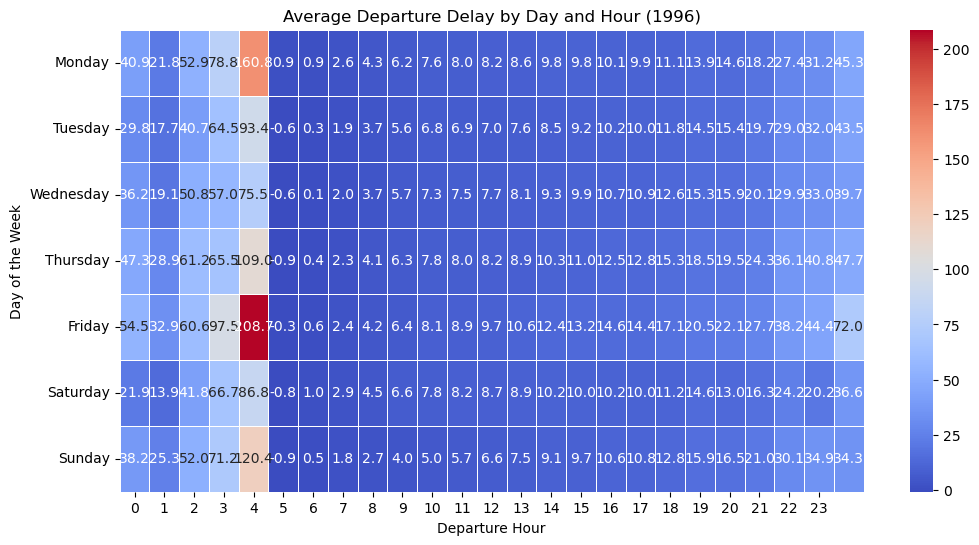

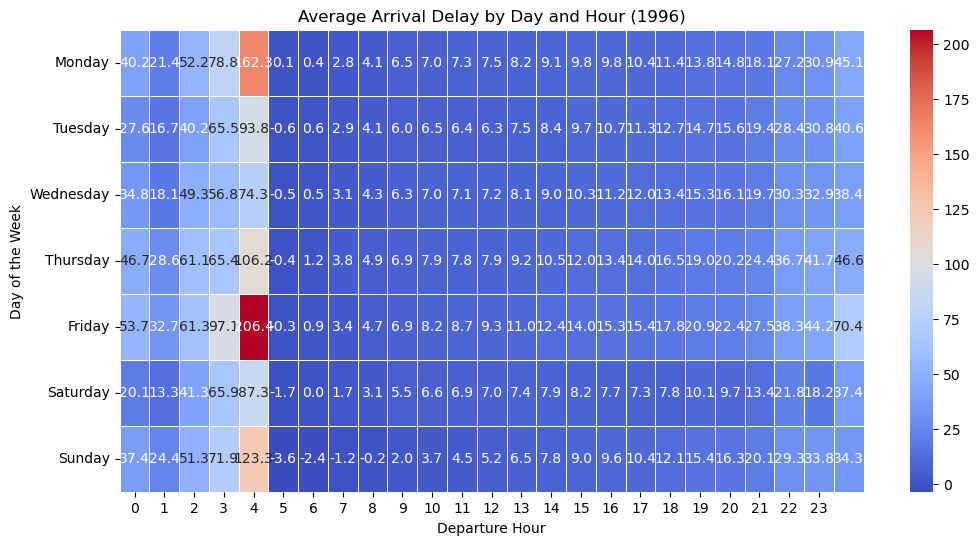

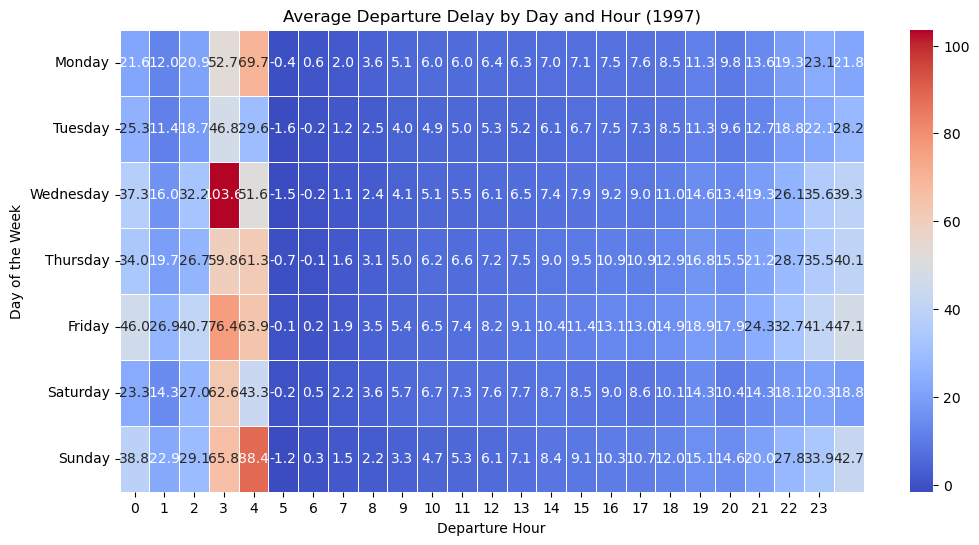

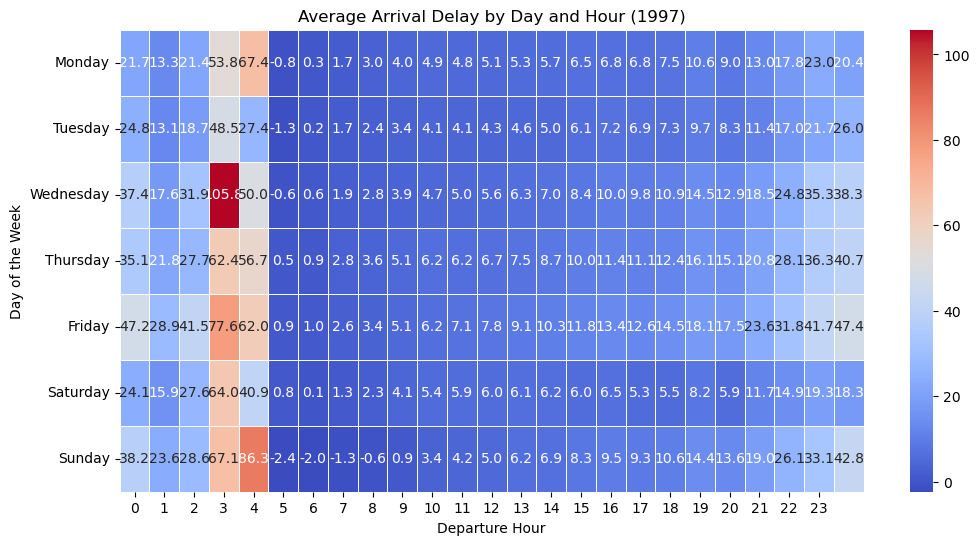

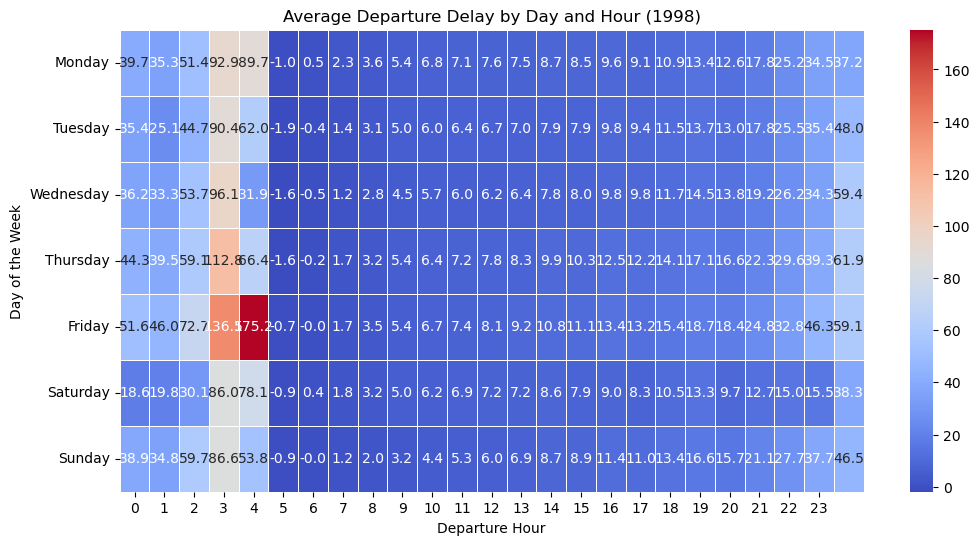

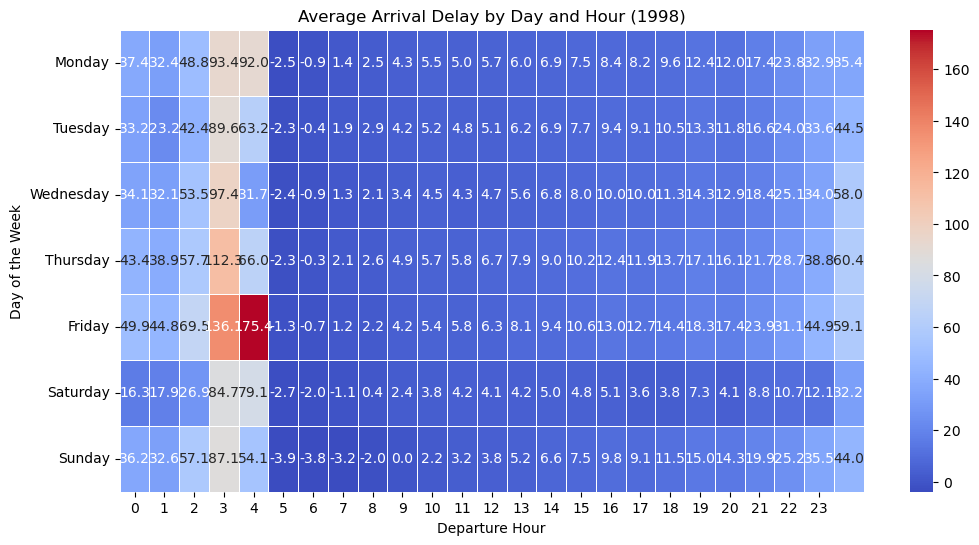

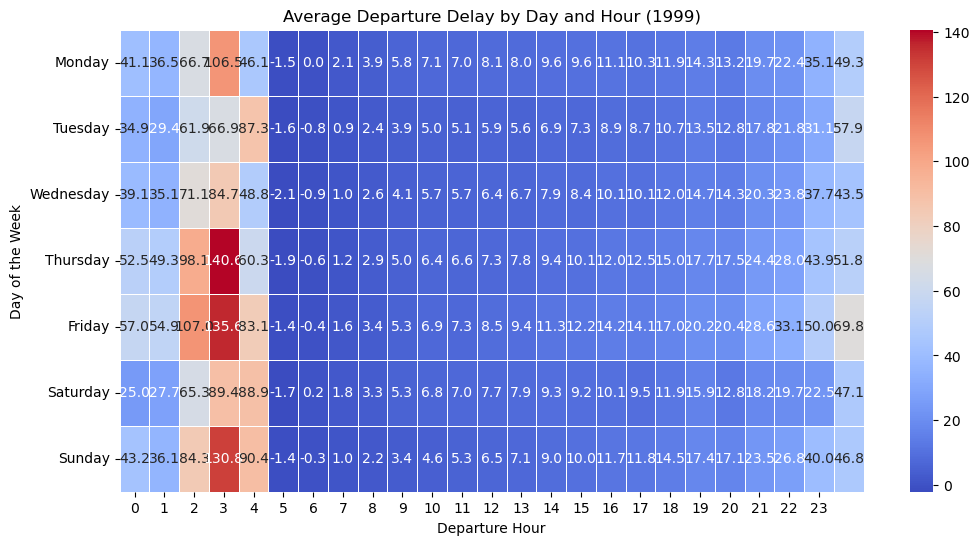

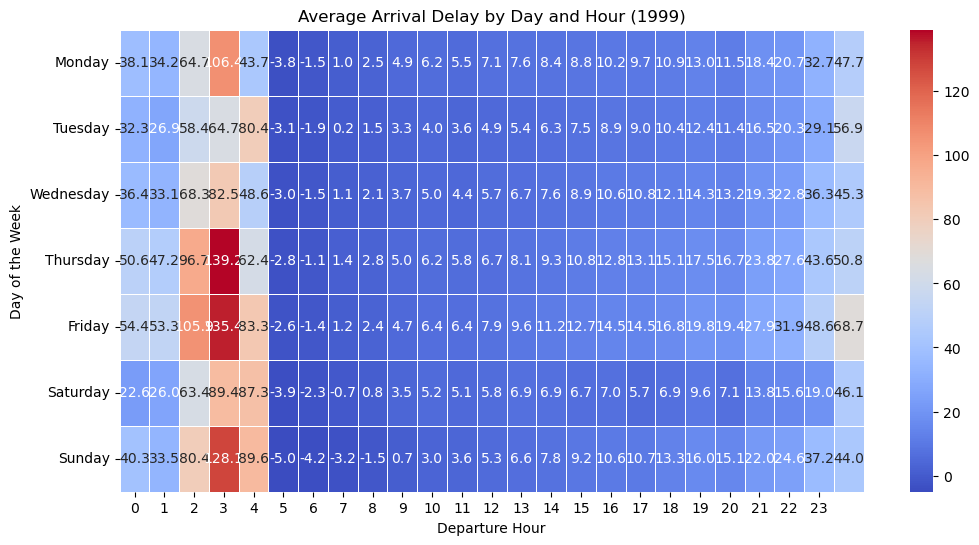

In [14]:
for year in range(1995, 2000):
    filename = f"{year}.csv"
    
    if os.path.exists(filename):
        try:
            df = pd.read_csv(filename, low_memory=False, encoding="utf-8")
        except UnicodeDecodeError:
            print(f"Warning: Encoding issue in {filename}. Trying 'latin1' encoding.")
            df = pd.read_csv(filename, low_memory=False, encoding="latin1")
    else:
        print(f"Warning: File {filename} not found. Skipping...")
        continue

    df = df.dropna(subset=["DepTime", "DepDelay", "ArrDelay"])
    
    df["DepHour"] = (df["DepTime"] // 100).astype(int)
    
    df["DayOfWeekName"] = df["DayOfWeek"].map(weekday_names)

    delay_by_time_dep = df.groupby(["DayOfWeek", "DepHour"]).agg({"DepDelay": "mean"}).reset_index()
    delay_pivot_dep = delay_by_time_dep.pivot(index="DayOfWeek", columns="DepHour", values="DepDelay")
    
    delay_by_time_arr = df.groupby(["DayOfWeek", "DepHour"]).agg({"ArrDelay": "mean"}).reset_index()
    delay_pivot_arr = delay_by_time_arr.pivot(index="DayOfWeek", columns="DepHour", values="ArrDelay")
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(delay_pivot_dep, cmap="coolwarm", annot=True, fmt=".1f", linewidths=0.5, xticklabels=range(24), yticklabels=weekday_names.values())
    plt.title(f"Average Departure Delay by Day and Hour ({year})")
    plt.xlabel("Departure Hour")
    plt.ylabel("Day of the Week")
    plt.show()
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(delay_pivot_arr, cmap="coolwarm", annot=True, fmt=".1f", linewidths=0.5, xticklabels=range(24), yticklabels=weekday_names.values())
    plt.title(f"Average Arrival Delay by Day and Hour ({year})")
    plt.xlabel("Departure Hour")
    plt.ylabel("Day of the Week")
    plt.show()



**"DayOfWeekName"** makes Monday (1), Tuesday (2) ,..., Sunday (7). This allows for clearer visualising of the overall graph.<br><br>
**"df["TotalDelay"] = df["ArrDelay"] + df["DepDelay"]"** combine both ArrDelay and DepDelay to create an overall delay column.<br><br>
**"delay_by_time_all"** groups **"DayOfWeekName"** and **"DepHour"** and calculate mean arrival delay.<br><br>
**"delay_pivot_all"** creates a pivot table for heatmap, where each row corresponds to a day of the week, each column corresponds to a departure hour, and each cell shows the average delay for that combination.<br><br>
Plot a heatmap accordingly.


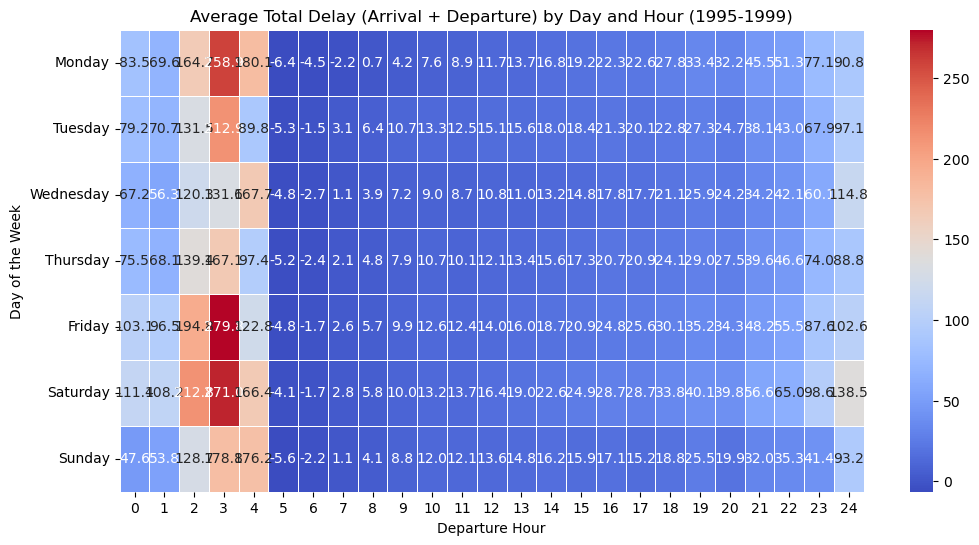

In [16]:
df.loc[:, "DayOfWeekAdjusted"] = (df["DayOfWeek"] + 1) % 7
df.loc[:, "DayOfWeekAdjusted"] = df["DayOfWeekAdjusted"].replace(0, 7)
df.loc[:, "DayOfWeekName"] = df["DayOfWeekAdjusted"].map(weekday_names)

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["DayOfWeekName"] = pd.Categorical(df["DayOfWeekName"], categories=weekday_order, ordered=True)

df["TotalDelay"] = df["ArrDelay"] + df["DepDelay"]

delay_by_time_all = df.groupby(["DayOfWeekName", "DepHour"], observed=False).agg({"TotalDelay": "mean"}).reset_index()

delay_pivot_all = delay_by_time_all.pivot(index="DayOfWeekName", columns="DepHour", values="TotalDelay")

plt.figure(figsize=(12, 6))
sns.heatmap(delay_pivot_all, cmap="coolwarm", annot=True, fmt=".1f", linewidths=0.5)
plt.title("Average Total Delay (Arrival + Departure) by Day and Hour (1995-1999)")
plt.xlabel("Departure Hour")
plt.ylabel("Day of the Week")
plt.show()

**"overall_weekday_delays"** calculates the average delay for each weekday over the 5-year period.<br><br>
Plot a bar chart accordingly.

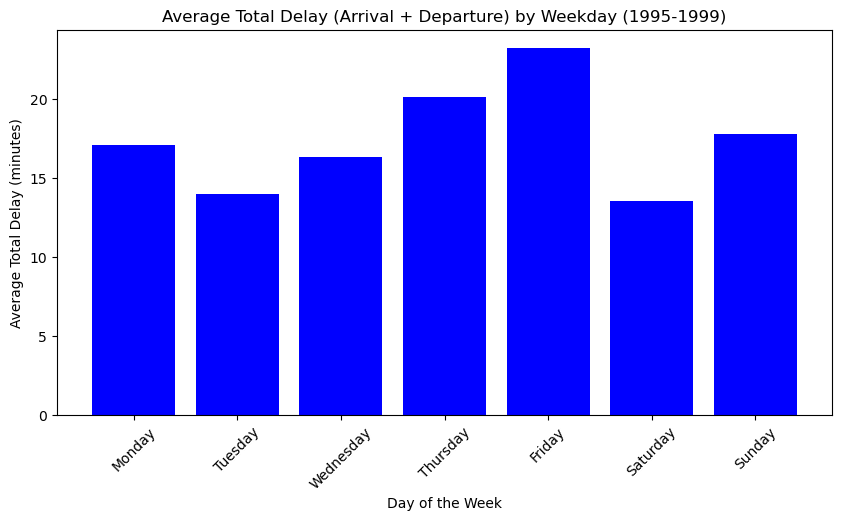

In [18]:
df["TotalDelay"] = df["ArrDelay"] + df["DepDelay"]

overall_weekday_delays = df.groupby("DayOfWeek")["TotalDelay"].mean()

overall_weekday_delays.index = overall_weekday_delays.index.map(weekday_names)

plt.figure(figsize=(10, 5))
plt.bar(overall_weekday_delays.index, overall_weekday_delays, color='blue')
plt.xlabel("Day of the Week")
plt.ylabel("Average Total Delay (minutes)")
plt.title("Average Total Delay (Arrival + Departure) by Weekday (1995-1999)")
plt.xticks(rotation=45)
plt.show()

## Question 2b) 

#### For part 2b), the objective is to analyse whether older aircraft experience increasing delays over the years.¶

Reload the dataset from above.<br><br>
Verify that the 5 year time frame is correct.

In [21]:
df = pd.concat(Empty_dictQ2ab.values(), ignore_index=True)
pdf1 = pd.read_csv("plane-data.csv")

print("Years in reloaded dataset:", df['Year'].unique())

Years in reloaded dataset: [1995 1996 1997 1998 1999]


**"oldplanedelay = df[['Year', 'DepDelay', 'ArrDelay', 'TailNum']].copy()"** selects the columns **'Year'**, **'DepDelay'**, **'ArrDelay'**, and **'TailNum'** from the **"df"** data frame and creates a copy of these columns in a new data frame named **"oldplanedelay"**.<br><br>
**"oldplanedelay['TotalDelay'] = oldplanedelay['DepDelay'] + oldplanedelay['ArrDelay']"** calculates the total delay for each row by adding the departure delay **(DepDelay)** and arrival delay **(ArrDelay)**. The result is stored in a new column named **'TotalDelay'**.<br><br>
**"oldplanedelay = oldplanedelay[oldplanedelay['TotalDelay'] >= 0][['Year', 'TotalDelay', 'TailNum']]"** filters the **"oldplanedelay"** data frame to include only rows where the total delay **(TotalDelay)** is greater than or equal to zero. It also selects only the columns **'Year'**, **'TotalDelay'**, and **'TailNum'** for further analysis.<br><br>
**"planedata = pdf1[['tailnum', 'issue_date']].dropna(subset=['issue_date'])"** selects the **'tailnum'** (TailNum) and **'issue_date'** columns from the **"pdf1"** data frame, which was read into program at the start. It then drops any rows with missing values in the **'issue_date'** column.

In [23]:
oldplanedelay = df[['Year', 'DepDelay', 'ArrDelay', 'TailNum']].copy()

oldplanedelay['TotalDelay'] = oldplanedelay['DepDelay'] + oldplanedelay['ArrDelay']

oldplanedelay = oldplanedelay[oldplanedelay['TotalDelay'] >= 0][['Year', 'TotalDelay', 'TailNum']]

planedata = pdf1[['tailnum', 'issue_date']].dropna(subset=['issue_date'])

print(planedata)
print(oldplanedelay)

     tailnum  issue_date
34    N10156  02/13/2004
35    N102UW  05/26/1999
36    N10323  07/01/1997
37    N103US  06/18/1999
38    N104UA  01/26/1998
...      ...         ...
5024  N997DL  03/11/1992
5025  N998AT  01/23/2003
5026  N998DL  04/02/1992
5027  N999CA  07/09/2008
5028  N999DN  04/02/1992

[4479 rows x 2 columns]
          Year  TotalDelay TailNum
0         1995        27.0  N7298U
1         1995         4.0  N7449U
6         1995        15.0  N7257U
7         1995         0.0  N7282U
8         1995         1.0  N7270U
...        ...         ...     ...
26323413  1999         1.0  N2BFAA
26323415  1999         5.0  N2AGAA
26323423  1999        85.0  N885AA
26323425  1999         0.0  N2DAAA
26323431  1999         5.0  N2BAAA

[14775229 rows x 3 columns]


**"planedata['issue_date'] = pd.to_datetime(planedata['issue_date'])"** converts issue_date to datetime format.<br><br>
**"planedata['ManufactureYear'] = planedata['issue_date'].dt.year"** extracts the manufacturing year.<br><br>
**"oldplanedelay = oldplanedelay.merge(planedata[['tailnum', 'ManufactureYear']], 
                                    left_on='TailNum', right_on='tailnum', how='left')"** merges manufacturing year with flight delay data.<br><br>
**"oldplanedelay['AircraftAge'] = oldplanedelay['Year'] - oldplanedelay['ManufactureYear']"** calculates aircraft age.<br><br>
**"dropna()"** removes invalid values (e.g., negative or NaN aircraft ages).<br><br>
Debug: Check if all years are present.

In [25]:
planedata['issue_date'] = pd.to_datetime(planedata['issue_date'])

planedata['ManufactureYear'] = planedata['issue_date'].dt.year

oldplanedelay = oldplanedelay.merge(planedata[['tailnum', 'ManufactureYear']], 
                                    left_on='TailNum', right_on='tailnum', how='left')

oldplanedelay['AircraftAge'] = oldplanedelay['Year'] - oldplanedelay['ManufactureYear']

oldplanedelay = oldplanedelay.dropna(subset=['AircraftAge'])
oldplanedelay = oldplanedelay[oldplanedelay['AircraftAge'] >= 0]

print(oldplanedelay['Year'].unique())

[1995 1996 1997 1998 1999]


Define and categorise age categories.

In [27]:
bins = [0, 10, 20, float('inf')]
labels = ['Young', 'Middle', 'Old']

oldplanedelay['AgeCategory'] = pd.cut(oldplanedelay['AircraftAge'], bins=bins, labels=labels, right=True)

**"mean_delay_by_age"** to compute the mean delay by age category.<br><br>
Plot the bar charts and annotate bars with exact values.

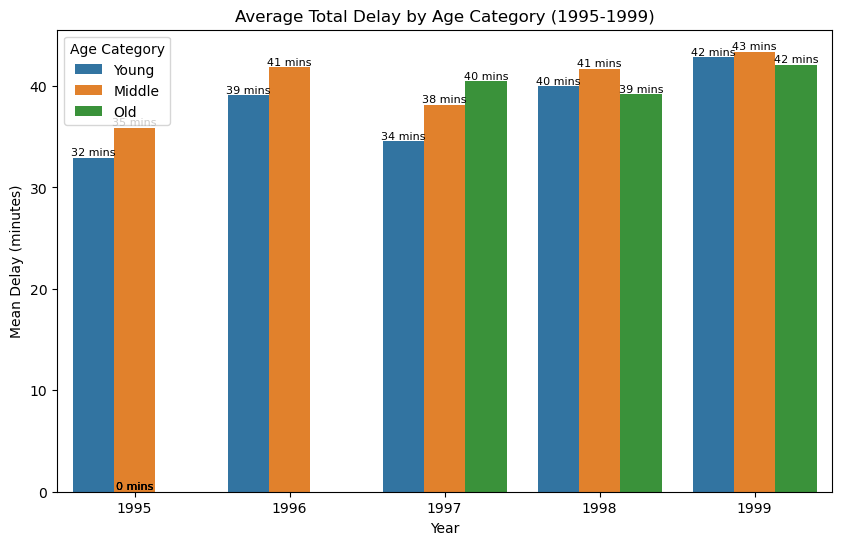

In [29]:
mean_delay_by_age = oldplanedelay.groupby(['Year', 'AgeCategory'], observed=False)['TotalDelay'].mean().reset_index()

def plot_delay_chart(data, title):
    plt.figure(figsize=(10,6))
    sns.barplot(x='Year', y='TotalDelay', hue='AgeCategory', data=data)
    plt.xlabel("Year")
    plt.ylabel("Mean Delay (minutes)")
    plt.title(title)
    plt.legend(title="Age Category", loc='upper left')
    
    for p in plt.gca().patches:
        height = p.get_height()
        if not pd.isna(height):
            minutes = int(height)
            plt.gca().annotate(f"{minutes} mins", 
                               (p.get_x() + p.get_width() / 2, height),
                               ha='center', va='bottom', fontsize=8, color='black')

    plt.show()

plot_delay_chart(mean_delay_by_age, "Average Total Delay by Age Category (1995-1999)")

Find the category with the highest average total delay for each year and print results accordingly.

In [31]:
highest_delays = mean_delay_by_age.loc[mean_delay_by_age.groupby("Year")["TotalDelay"].idxmax()]

for _, row in highest_delays.iterrows():
    minutes = int(row["TotalDelay"])
    seconds = int((row["TotalDelay"] - minutes) * 60) 
    print(f"Year {int(row['Year'])}: {row['AgeCategory']} has the highest average total delay of {minutes}:{seconds:02d}.")


Year 1995: Middle has the highest average total delay of 35:52.
Year 1996: Middle has the highest average total delay of 41:52.
Year 1997: Old has the highest average total delay of 40:27.
Year 1998: Middle has the highest average total delay of 41:41.
Year 1999: Middle has the highest average total delay of 43:23.


**"anova_table = sm.stats.anova_lm(model, typ=2)"** computes the ANOVA table using the fitted SMF OLS regression model. The typ=2 argument specifies the type 2 ANOVA, which considers each variable's contribution while controlling for other variables in the model.

In [33]:
model = smf.ols("TotalDelay ~ C(AgeCategory) + C(Year)", data=oldplanedelay).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                      sum_sq         df            F        PR(>F)
C(AgeCategory)  9.217484e+05        2.0    95.413278  3.663111e-42
C(Year)         3.618618e+07        4.0  1872.876719  0.000000e+00
Residual        1.457612e+10  3017647.0          NaN           NaN


**"CSVs = [f"{year}Q2ab.csv" for year in range(1995, 2000)]"** generates a list of file names by iterating over years from 1995 to 1999 and formatting each year into the filename pattern **"{year}Q2AB.csv"**.<br><br>
**"directory_path = os.getcwd()"** retrieves the current working directory path using the os.getcwd() function.<br><br>
The code then shows the files to be deleted along with the question asking the user whether they want to delete or not.<br><br>
The code displays the files scheduled for deletion and asks the user whether they wish to proceed.<br>-If the user enters 'Y', confirming deletion, the code proceeds to remove the files.<br>-If the user enters 'N', canceling the action, a message is displayed, and the loop is exited.<br>-If the input is neither 'Y' nor 'N', the user is repeatedly prompted to enter a valid response until one is received.

For each file in the list, the full file path is generated using os.path.join(), and os.remove() attempts to delete it.<br>-If the deletion is successful, a confirmation message is printed.<br>-If the file is not found, an appropriate message is displayed.<br>-Once all files are deleted, a final confirmation message is shown.

In [35]:
CSVs = [f"{year}Q2ab.csv" for year in range(1995, 2000)]

directory_path = os.getcwd()

print("Files to be deleted:")
for CSV in CSVs:
    print(CSV)

confirmation = input("Do you want to delete the following files? (Y/N): ").lower()

while confirmation != 'y':
    if confirmation == 'n':
        print("Deletion cancelled. Run the code again to delete. Thank you.")
        break
    else:
        confirmation = input("Invalid input. Please enter 'Y' or 'N': ").lower()

if confirmation == 'y':
    for CSV in CSVs:
        CSV_path = os.path.join(directory_path, CSV)
        try:
            os.remove(CSV_path)
            print(f"Deleted: {CSV}")
        except FileNotFoundError:
            print(f"File not found: {CSV}")

    print("Task completed! Cleaned files deleted.")

Files to be deleted:
1995Q2ab.csv
1996Q2ab.csv
1997Q2ab.csv
1998Q2ab.csv
1999Q2ab.csv


Do you want to delete the following files? (Y/N):  Y


Deleted: 1995Q2ab.csv
Deleted: 1996Q2ab.csv
Deleted: 1997Q2ab.csv
Deleted: 1998Q2ab.csv
Deleted: 1999Q2ab.csv
Task completed! Cleaned files deleted.


## Question 2c)
#### For part 2c), the objective is to fit a logistic regression model each year to predict the probability of diverted US flights. The model will incorporate as many features as possible, including departure date attributes, scheduled departure and arrival times, airport coordinates, distance between departure and planned arrival locations, and the carrier. The coefficients will be visualized across different years.

**"CSVs = [f"{year}Q2c.csv" for year in range(1995, 2000)]"** generates a list of CSV file names for each year between 1995 and 1999.<br><br>
**"Columns_Needed = [
    "Month", "DayofMonth", "CRSDepTime", "CRSArrTime", "Distance",
    "UniqueCarrier", "Origin", "Dest", "Year", "Diverted"
]"** defines the specific columns you want to keep in your dataset for each year.

In [38]:
CSVs = [f"{year}Q2c.csv" for year in range(1995, 2000)]

Columns_Needed = [
    "Month", "DayofMonth", "CRSDepTime", "CRSArrTime", "Distance",
    "UniqueCarrier", "Origin", "Dest", "Year", "Diverted"
]

**"coefficients = {}"** initializes an empty list named coefficients. It is intended to store coefficients obtained from some computation or model fitting process.<br><br>
**"years_list = []"** initializes an empty list named years_list.

In [40]:
coefficients = {}

years_list = []

Create a **“for”** loop to loop through range of years from 1995 to 1999. The following code explanation below are all within the loop.

To read and process data: **“CSV_path = f"{year}Q2c.csv"”** constructs the path to the CSV file corresponding to the current year. **“pd.read_csv(CSV_path, encoding="utf-8")”** reads the CSV file into a data frame.

Select and clean the data.

Convert the categorical columns to numeric.

Define feature matrix X and target variable y.

Remove variables with zero variance (e.g., ‘Year’).

Store feature names for mapping back after scaling

Now to split data and fit model, split the data into training and testing sets using train_test_split, and standardise the features using **"StandardScaler()"**.

Fit logistic regression model using statsmodels.

Extract coefficients and map back to original feature names.

Lastly, print the coefficient for each feature obtained from the logistic regression model for the current year, and go on to the next year, till the last year 1999’s data is computed.

In [42]:
for year in range(1995, 2000):
    CSV_path = f"{year}Q2c.csv"

    try:
        lrdf_year = pd.read_csv(CSV_path, encoding="utf-8")
    except Exception as e:
        print(f"Error reading file for year {year}: {e}")
        continue 
        
    if not set(Columns_Needed).issubset(lrdf_year.columns):
        print(f"Skipping {year}, missing required columns")
        continue
    
    lrdf_year = lrdf_year[Columns_Needed].dropna()

    categorical_columns = ["Month", "DayofMonth", "UniqueCarrier", "Origin", "Dest"]
    for col in categorical_columns:
        lrdf_year[col] = lrdf_year[col].astype("category").cat.codes

    X = lrdf_year.drop(columns=["Diverted"])
    y = lrdf_year["Diverted"]

    X = X.loc[:, X.var() != 0]

    feature_names = X.columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_sm = sm.add_constant(X_train_scaled)  
    model = sm.Logit(y_train, X_train_sm).fit(disp=0)  
    
    coef_values = dict(zip(feature_names, model.params[1:]))  
    coefficients[str(year)] = coef_values  
    years_list.append(year)

    print(f"Coefficients for {year}:")
    for feature, coef in coef_values.items():
        print(f"{feature}: {coef}")
    print("\n")


Coefficients for 1995:
Month: -0.0450318292282728
DayofMonth: -0.05882225123186723
CRSDepTime: 0.036062500121846024
CRSArrTime: -0.038997831257622254
Distance: 0.31083119462901165
UniqueCarrier: 0.010445504088862695
Origin: -0.012236528575051121
Dest: 0.0337447242518104


Coefficients for 1996:
Month: -0.07405568476209767
DayofMonth: 0.043843644450481216
CRSDepTime: -0.0224786326003319
CRSArrTime: 0.03888314635374962
Distance: 0.3150405201501788
UniqueCarrier: -0.013386882086998089
Origin: -0.010306599615930669
Dest: -0.002879645425197614


Coefficients for 1997:
Month: -0.07416801128918513
DayofMonth: 0.03903270506992524
CRSDepTime: -0.04487761543692876
CRSArrTime: 0.11733027147674288
Distance: 0.2981805132312217
UniqueCarrier: -0.08140672256878381
Origin: -0.008189651224951237
Dest: -0.02108469165173496


Coefficients for 1998:
Month: -0.05897794555600273
DayofMonth: -0.003512613899401113
CRSDepTime: -0.01732637380036422
CRSArrTime: 0.1177353367610546
Distance: 0.38503524127056044
Un

**"coefficients_df = pd.DataFrame.from_dict(coefficients, orient='index')"** converts the coefficients dictionary into a Pandas DataFrame, treating dictionary keys as the index.<br><br>
**"coefficients_df.reset_index(inplace=True)"** resets the index of **"coefficients_df"**, moving the current index (dictionary keys) into a regular column.<br><br>
**"coefficients_df.rename(columns={"index": "Year"}, inplace=True)"** renames the **"index"** column to **"Year"** to make the DataFrame more readable and meaningful.<br><br>
**"coefficients_df["Year"] = coefficients_df["Year"].astype(int)"** converts the **"Year"** column to an integer data type to ensure consistency and correct sorting.<br><br>
**"long_df = coefficients_df.melt(id_vars=["Year"], var_name="Feature", value_name="Coefficient")"**  transforms **"coefficients_df"** from a wide format to a long format, where each row represents a single feature's coefficient for a given year.<br><br>
Plot the bar chart accordingly.

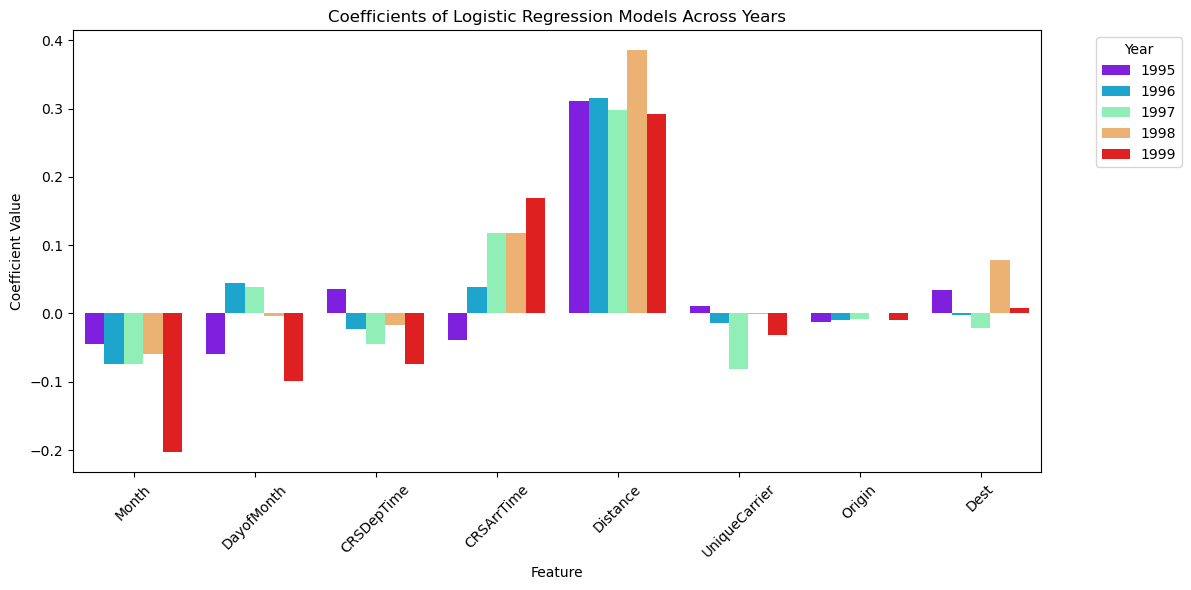

In [44]:
coefficients_df = pd.DataFrame.from_dict(coefficients, orient='index')
coefficients_df.reset_index(inplace=True)
coefficients_df.rename(columns={"index": "Year"}, inplace=True)
coefficients_df["Year"] = coefficients_df["Year"].astype(int)

long_df = coefficients_df.melt(id_vars=["Year"], var_name="Feature", value_name="Coefficient")

plt.figure(figsize=(12, 6))
sns.barplot(data=long_df, x="Feature", y="Coefficient", hue="Year", dodge=True, palette="rainbow")
plt.title("Coefficients of Logistic Regression Models Across Years")
plt.xlabel("Feature")
plt.ylabel("Coefficient Value")
plt.xticks(rotation=45)
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()